In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Load datasets
df0 = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')
nyc_preds_means = pd.read_csv('nyc_preds_means.csv')

df0 = df0.merge(nyc_preds_means, left_index=True, right_index=True)

df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,...,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.847222,3.521667,16.434245
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,...,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470370,3.108889,16.052218
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,...,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250000,0.881429,7.053706
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,...,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.731650
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,...,16.5,0.5,0.5,0.00,0.0,0.3,17.80,14.616667,4.435000,15.845642


In [ ]:

df1 = df0.copy()
df1 = df1[df1['payment_type'] == 1]

df1['tip_percent'] = df1['tip_amount'] / (df1['total_amount'] - df1['tip_amount'])
df1['tip_percent'] = round(df1['tip_percent'], 3) # Round to avoid float errors

# Create 'generous' target: 1 if tip >= 20%, 0 otherwise
df1['generous'] = (df1['tip_percent'] >= 0.20).astype(int)


df1['generous'].value_counts(normalize=True)

generous
1    0.526368
0    0.473632
Name: proportion, dtype: float64

In [3]:
df1['tpep_pickup_datetime'] = pd.to_datetime(df1['tpep_pickup_datetime'])
df1['tpep_dropoff_datetime'] = pd.to_datetime(df1['tpep_dropoff_datetime'])

# Create day of week and hour
df1['day'] = df1['tpep_pickup_datetime'].dt.day_name().str.lower()
df1['hour'] = df1['tpep_pickup_datetime'].dt.hour

# Create rush hour bins
df1['am_rush'] = ((df1['hour'] >= 6) & (df1['hour'] < 10)).astype(int)
df1['daytime'] = ((df1['hour'] >= 10) & (df1['hour'] < 16)).astype(int)
df1['pm_rush'] = ((df1['hour'] >= 16) & (df1['hour'] < 20)).astype(int)
df1['nighttime'] = ((df1['hour'] >= 20) | (df1['hour'] < 6)).astype(int)

In [ ]:
# Updated list of columns to drop
cols_to_drop = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'payment_type', 
                'tip_amount', 'tip_percent', 'total_amount', 'tolls_amount', 
                'extra', 'mta_tax', 'improvement_surcharge', 'hour']


df2 = df1.drop(cols_to_drop, axis=1, errors='ignore')


df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15265 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          15265 non-null  int64  
 1   VendorID            15265 non-null  int64  
 2   passenger_count     15265 non-null  int64  
 3   trip_distance       15265 non-null  float64
 4   RatecodeID          15265 non-null  int64  
 5   store_and_fwd_flag  15265 non-null  object 
 6   PULocationID        15265 non-null  int64  
 7   DOLocationID        15265 non-null  int64  
 8   fare_amount         15265 non-null  float64
 9   mean_duration       15265 non-null  float64
 10  mean_distance       15265 non-null  float64
 11  predicted_fare      15265 non-null  float64
 12  generous            15265 non-null  int64  
 13  day                 15265 non-null  object 
 14  am_rush             15265 non-null  int64  
 15  daytime             15265 non-null  int64  
 16  pm_rush  

In [7]:
# 1. Convert categorical numeric IDs to strings
cols_to_str = ['RatecodeID', 'PULocationID', 'DOLocationID', 'VendorID']

for col in cols_to_str:
    df2[col] = df2[col].astype(str)

# 2. Convert all categorical columns to binary (0 or 1)
df2_dummies = pd.get_dummies(df2, drop_first=True)

In [ ]:
# Isolate target variable (y) and features (X)
y = df2_dummies['generous']
X = df2_dummies.drop('generous', axis=1)

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

In [10]:
# 1. Instantiate the classifier
rf = RandomForestClassifier(random_state=42)

# 2. Define hyperparameters
cv_params = {'max_depth': [None],
             'max_features': [1.0],
             'max_samples': [0.7],
             'min_samples_leaf': [1],
             'min_samples_split': [2],
             'n_estimators': [300]}

# 3. FIX: Change curly brackets {} to square brackets []
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Construct GridSearch
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')

# 5. Fit the model
rf_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'max_features': [1.0], 'max_samples': [0.7], 'min_samples_leaf': [1], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [11]:
from sklearn import metrics

# 1. Use the best model to predict on test data
rf_preds = rf_cv.best_estimator_.predict(X_test)

# 2. Print evaluation metrics
print('Accuracy Score:', metrics.accuracy_score(y_test, rf_preds))
print('Precision Score:', metrics.precision_score(y_test, rf_preds))
print('Recall Score:', metrics.recall_score(y_test, rf_preds))
print('F1 Score:', metrics.f1_score(y_test, rf_preds))

Accuracy Score: 0.6986570586308549
Precision Score: 0.6793733681462141
Recall Score: 0.8095830740510268
F1 Score: 0.7387847813742192


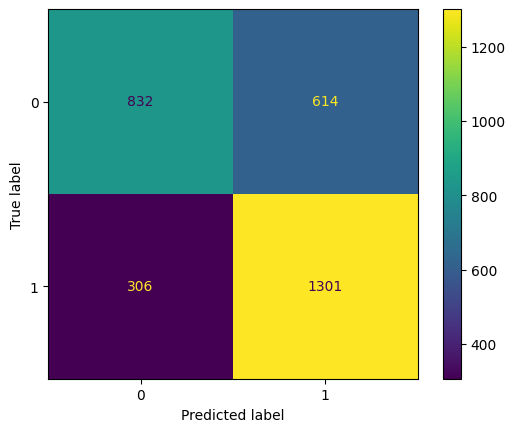

In [12]:
# Create and display the confusion matrix
cm = metrics.confusion_matrix(y_test, rf_preds)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.classes_)

# Plot the visual
disp.plot(values_format='')

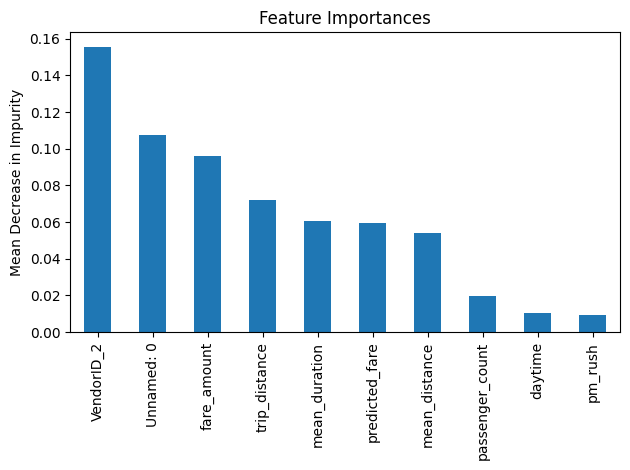

In [13]:
# Get feature importances from the best estimator
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X_test.columns)

# Sort and plot the top 10 most important features
fig, ax = plt.subplots()
rf_importances.sort_values(ascending=False).head(10).plot.bar(ax=ax)
ax.set_title('Feature Importances')
ax.set_ylabel('Mean Decrease in Impurity')
fig.tight_layout()